# MathWriting Data Pipeline

Converts the MathWriting InkML dataset into model-ready inputs:
1. **PNGs** — each ink rescaled to a fixed height (aspect ratio preserved, no letterboxing/squashing to a square), rendered as grayscale line art.
2. **Tokenized labels** — each `normalizedLabel` (or `label` for `symbols/`, which has no normalized version) split into LaTeX tokens and mapped to integer ids via a frozen vocabulary.
3. **A calibrated augmentation utility** — rotation, shear, stroke thinning, and Gaussian blur, each independently randomized and composable, ready to call from a training-time `Dataset`.

Pipeline stages, in order:
- Download the dataset if it isn't already present locally (never committed to the repo)
- Read InkML files (strokes + annotations)
- Geometrically normalize each ink (fixed height, preserved aspect ratio)
- Rasterize to PNG (Cairo if available, otherwise a Pillow fallback)
- Tokenize labels with the official regex tokenizer
- Build a vocabulary from `train` + `synthetic` only (never from `valid`/`test`)
- Write per-split `.jsonl` label files + `vocab.json` + `metadata.json`
- Run sanity checks (tokenizer round-trip, split disjointness, distribution stats)
- Spot-check a few rendered images against their labels
- Define + visually QA the augmentation utility used at training time

`train`/`valid`/`test`/`synthetic`/`symbols` are processed independently and never merged — the official splits already account for writer and expression overlap, so we preserve them exactly as given.

**On augmentation:** `processed/images/` holds only *clean* (unaugmented) renders for every split, including `train`. Augmentation is intentionally **not** baked into these PNGs — it's applied online, at training time, by calling `render_with_augmentation` fresh for each `train` example on each epoch (see the dedicated section below). This gives unbounded diversity across epochs instead of a fixed set of pre-baked copies, and keeps `processed/` simple: one clean image per sample, always.

## Setup

Detects whether `pycairo` is usable and installs any of the small set of dependencies that aren't already available. Cairo gives higher-fidelity anti-aliased rendering (matching the official example notebook), but its system library is often unavailable on Windows, so we fall back to a supersampled Pillow renderer instead of failing.

In [1]:
try:
    import PIL, numpy, matplotlib  # noqa: F401
except ImportError:
    %pip install -q pillow numpy matplotlib

try:
    import cairo  # noqa: F401
    _CAIRO_AVAILABLE = True
except ImportError:
    try:
        %pip install -q pycairo
        import cairo  # noqa: F401
        _CAIRO_AVAILABLE = True
    except Exception as e:
        print(f"pycairo unavailable ({e!r}); using the Pillow fallback renderer instead.")
        _CAIRO_AVAILABLE = False

print(f"Using {'Cairo' if _CAIRO_AVAILABLE else 'Pillow (supersampled)'} for rendering.")

Using Cairo for rendering.


## Download the dataset

The dataset is a public Google Cloud Storage bucket `mathwriting-2024`

In [2]:
import tarfile
import urllib.request
from pathlib import Path

DATASET_URL = "https://storage.googleapis.com/mathwriting_data/mathwriting-2024.tgz"
ROOT_DIR = Path("mathwriting-2024")

if not ROOT_DIR.exists():
    archive_name = Path(DATASET_URL).name
    print(f"'{ROOT_DIR}' not found locally; downloading from {DATASET_URL} ...")
    urllib.request.urlretrieve(DATASET_URL, archive_name)
    print(f"Downloaded {archive_name}; extracting...")
    with tarfile.open(archive_name) as tar:
        tar.extractall(".")
    print(f"Extracted to '{ROOT_DIR}'.")
    # Not needed after extraction (and .gitignore'd, same as the extracted
    # dataset) -- delete it to reclaim disk space, since the full dataset's
    # archive is a few GB.
    Path(archive_name).unlink()
    print(f"Removed {archive_name} (no longer needed).")
else:
    print(f"'{ROOT_DIR}' already present, skipping download.")

'mathwriting-2024' not found locally; downloading from https://storage.googleapis.com/mathwriting_data/mathwriting-2024.tgz ...


Downloaded mathwriting-2024.tgz; extracting...


C:\Users\ryanc\AppData\Local\Temp\ipykernel_14780\2607430662.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(".")


Extracted to 'mathwriting-2024'.
Removed mathwriting-2024.tgz (no longer needed).


## Imports & configuration

All the tunable constants live here. Notes on a few choices:
- `TARGET_HEIGHT=64`: based on measuring this excerpt's actual ink aspect ratios (median ~3.2:1, p99 ~6.5:1), this keeps p99 widths around ~420px — a reasonable size for a MobileNetV3 encoder.
- Per-image widths are **not** padded or rounded here — we store each image's true (unpadded) width in the label files, and defer batch padding + the padding mask to the training-time collate function, where the batch's max width gets rounded up to a multiple of 32 (MobileNetV3's stride).
- `VOCAB_SPLITS = ["train", "synthetic"]`: the vocabulary is built only from data intended for training, per the dataset README's own guidance. `valid`/`test` tokens never influence the vocab — unseen tokens there become `<UNK>`, which is itself a useful generalization signal.

In [3]:
import re
import math
import json
import time
import itertools
import dataclasses
from collections import Counter
from xml.etree import ElementTree

import numpy as np
from PIL import Image, ImageDraw, ImageFilter
import matplotlib.pyplot as plt

from mathwriting_pipeline import (
    Ink, read_inkml_file,
    rescale_to_height, fit_canvas,
    render_ink, CAIRO_AVAILABLE,
    apply_affine_ink, thin_strokes, gaussian_blur,
    AUGMENTATION_CONFIG, render_with_augmentation, RNG_SEED,
    tokenize_expression, get_label_text,
    TARGET_HEIGHT, STROKE_WIDTH_PX, MARGIN_PX, SUPERSAMPLE,
)

# --- Paths ---
OUTPUT_DIR = Path("processed")

# `symbols/` has no `normalizedLabel` (only `label`); the rest have both.
ALL_SPLITS = ["train", "valid", "test", "synthetic", "symbols"]
VOCAB_SPLITS = ["train", "synthetic"]

# --- Special tokens ---
PAD_TOKEN, BOS_TOKEN, EOS_TOKEN, UNK_TOKEN = "<PAD>", "<BOS>", "<EOS>", "<UNK>"
SPECIAL_TOKENS = [PAD_TOKEN, BOS_TOKEN, EOS_TOKEN, UNK_TOKEN]

for split in ALL_SPLITS:
    (OUTPUT_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "labels").mkdir(parents=True, exist_ok=True)

## Reading InkML files

Adapted directly from the official example notebook: each file's `<trace>` elements become stroke arrays of shape `(2, num_points)` (x, y — we drop the timestamp, which this pipeline doesn't use), and `<annotation>` elements become the metadata dict (`label`, `normalizedLabel`, `sampleId`, etc.).

## Geometric normalization

Raw InkML coordinates are unnormalized (readme: "vertical extent of a given letter can vary greatly depending on the ink and writer"). We rescale each ink **uniformly** (same factor for x and y, so nothing gets stretched or squashed) so its bounding-box height equals `TARGET_HEIGHT`, then shift it into a small margin. Width is whatever falls out of that — we deliberately don't force a square or a fixed canvas.

This is split into two composable pieces — `rescale_to_height` (pure scale-to-`TARGET_HEIGHT`) and `fit_canvas` (shift into the margin + measure canvas size) — so augmentation (below) can slot in *between* them: normalize height first, jitter geometry second, then re-fit the canvas to the jittered result.

## Rendering

Two renderers with the same signature, dispatched on `_CAIRO_AVAILABLE`:
- **Cairo** (`_render_with_cairo`): same approach as the official example notebook — round line caps/joins, natively anti-aliased.
- **Pillow fallback** (`_render_with_pillow`): draws at `SUPERSAMPLE`× resolution (a disk at every point plus a curved polyline, to approximate round caps/joins) then downsamples with Lanczos — a standard way to fake anti-aliasing without any system library dependency.

Both output a single-channel (`"L"`) grayscale image: black strokes on a white background, no color information to carry.

## Augmentation

- `apply_affine_ink` rotates/shears strokes around the ink's own bounding-box center — a single 2×2 linear map. This runs on vector stroke coordinates, then the result is re-rendered from scratch, which avoids the blur/interpolation artifacts of warping a finished raster image.
- `thin_strokes` erodes strokes by re-rendering at supersampled resolution, running a 3×3 max-filter pass per iteration there, then downsampling back down. Eroding directly at the final ~64px resolution is too coarse: a single max-filter pass removes close to a full pixel of a ~2.5px-wide stroke, wiping it out after 2-3 iterations. Supersampling first makes each iteration a much finer, sub-pixel-equivalent nibble.
- `gaussian_blur` is a plain `ImageFilter.GaussianBlur` on the rendered image.

its all in mathwriting_pipeline.py now

## Augmentation: policy

Each transform rolls **independently** with its own probability, and any subset can stack on a given sample — there's no "pick exactly one" or "always apply all." Ranges come straight from calibration:

| transform | mechanism | range | probability |
|---|---|---|---|
| rotation | ink-level affine | ±6° | 0.5 |
| shear | ink-level affine | ±8° | 0.4 |
| thinning | pixel-space erosion | 1–3 iterations (int) | 0.3 |
| blur | pixel-space Gaussian | radius 0.3–1.0 | 0.3 |

Rotation/shear are symmetric around 0, so a continuous draw from their range already includes near-zero outcomes — `prob` mainly controls how often a *given* sample moves away from that. Thinning/blur have no "off" value inside their calibrated range at all (there's no such thing as -1 blur), so for those two `prob` alone decides clean-vs-degraded for that sample.

**This is meant to be called at training time**, once per `train` example per epoch (e.g. from a `Dataset.__getitem__`), passing a fresh `np.random.Generator` draw each call — not run once here to bake a fixed augmented copy to disk. That's why `processed/images/train/` (built further down) stays clean: it's the frozen geometry+label source a training `Dataset` reads from, and this function is what that `Dataset` calls on top of it.

## Tokenizer

The official regex tokenizer, unchanged: splits a LaTeX string into meaningful units (`\frac`, `\alpha`, single characters, etc.) rather than raw characters.

## Per-split processing

For every InkML file in a split: read it, normalize+render it to `processed/images/{split}/{sample_id}.png`, tokenize its label, and collect a record. This produces the **clean** (unaugmented) baseline for every split, including `train` — augmentation is applied later, on top of this, at training time (see above). Vocabulary lookup happens later, in its own cell — this function only tokenizes, it doesn't assign ids yet.

In [4]:
def process_split(split: str, progress_every: int = 5000) -> list:
    split_dir = ROOT_DIR / split
    image_dir = OUTPUT_DIR / "images" / split
    records = []

    filenames = sorted(p for p in split_dir.iterdir() if p.suffix == ".inkml")
    n = len(filenames)
    t0 = time.perf_counter()
    for i, path in enumerate(filenames):
        sample_id = path.stem
        ink = read_inkml_file(path)

        normalized_ink = rescale_to_height(ink)
        canvas_ink, width, height = fit_canvas(normalized_ink)
        image = render_ink(canvas_ink, width, height)
        image.save(image_dir / f"{sample_id}.png")

        label = get_label_text(ink.annotations)
        tokens = tokenize_expression(label)

        records.append({
            "sample_id": sample_id,
            "split": split,
            "label": ink.annotations.get("label"),
            "normalized_label": ink.annotations.get("normalizedLabel"),  # None for symbols/
            "tokens": tokens,
            "width": width,
            "height": height,
            "num_strokes": len(normalized_ink.strokes),
        })

        # Large splits (the full dataset, not the excerpt) can run for many
        # minutes with no other output -- a periodic progress/ETA line makes
        # that visible instead of silent.
        if progress_every and (i + 1) % progress_every == 0:
            elapsed = time.perf_counter() - t0
            rate = (i + 1) / elapsed
            eta = (n - (i + 1)) / rate if rate > 0 else float("nan")
            print(f"    {split}: {i + 1}/{n} ({elapsed:.0f}s elapsed, {rate:.1f} ink/s, ~{eta:.0f}s remaining)")

    return records

## Run processing over all splits

This is the actual (potentially slow) work — reading every InkML file and rendering every PNG. `train`/`valid`/`test`/`synthetic`/`symbols` are each processed independently into their own output subfolder; nothing here mixes them.

Timed with `time.perf_counter()` (monotonic, meant for measuring durations) per split, so we know where the time actually goes rather than just a single total. This is CPU-bound rendering work, not network-bound like the download step above, so it's a meaningful number to extrapolate from when estimating a run over the full (non-excerpt) dataset.

In [5]:
PIPELINE_TIMING = {"per_split_seconds": {}}
_pipeline_t0 = time.perf_counter()

records_by_split = {}
for split in ALL_SPLITS:
    print(f"Processing '{split}'...")
    _split_t0 = time.perf_counter()
    records_by_split[split] = process_split(split)
    split_elapsed = time.perf_counter() - _split_t0
    PIPELINE_TIMING["per_split_seconds"][split] = split_elapsed
    n = len(records_by_split[split])
    print(f"  {n} inks -> {OUTPUT_DIR / 'images' / split}  ({split_elapsed:.2f}s, {1000 * split_elapsed / n:.1f} ms/ink)")

PIPELINE_TIMING["processing_seconds"] = sum(PIPELINE_TIMING["per_split_seconds"].values())
print(f"\nTotal rendering time: {PIPELINE_TIMING['processing_seconds']:.2f}s")

Processing 'train'...


    train: 5000/229864 (83s elapsed, 60.1 ink/s, ~3740s remaining)


    train: 10000/229864 (167s elapsed, 60.0 ink/s, ~3666s remaining)


    train: 15000/229864 (281s elapsed, 53.3 ink/s, ~4030s remaining)


    train: 20000/229864 (368s elapsed, 54.3 ink/s, ~3863s remaining)


...

    synthetic: 390000/396014 (23575s elapsed, 16.5 ink/s, ~364s remaining)


    synthetic: 395000/396014 (23703s elapsed, 16.7 ink/s, ~61s remaining)


  396014 inks -> processed\images\synthetic  (23740.51s, 59.9 ms/ink)
Processing 'symbols'...


    symbols: 5000/6423 (78s elapsed, 64.2 ink/s, ~22s remaining)


  6423 inks -> processed\images\symbols  (100.76s, 15.7 ms/ink)

Total rendering time: 27941.99s


## Vocabulary construction

Built only from `VOCAB_SPLITS` (`train` + `synthetic`). Token ids: special tokens first (`<PAD>=0, <BOS>=1, <EOS>=2, <UNK>=3`), then every observed token ordered by frequency (most common first, alphabetical tiebreak) for a deterministic, reproducible mapping.

In [6]:
_vocab_t0 = time.perf_counter()


def build_vocab(splits: list) -> dict:
    counts = Counter()
    for split in splits:
        for rec in records_by_split[split]:
            counts.update(rec["tokens"])

    ordered_tokens = [tok for tok, _ in sorted(counts.items(), key=lambda kv: (-kv[1], kv[0]))]

    vocab = {tok: idx for idx, tok in enumerate(SPECIAL_TOKENS)}
    for tok in ordered_tokens:
        vocab[tok] = len(vocab)

    return vocab


vocab = build_vocab(VOCAB_SPLITS)
print(f"Vocab size (built from {VOCAB_SPLITS}): {len(vocab)}")

with open(OUTPUT_DIR / "vocab.json", "w", encoding="utf-8") as f:
    json.dump(vocab, f, ensure_ascii=False, indent=2)

PIPELINE_TIMING["vocab_build_seconds"] = time.perf_counter() - _vocab_t0

Vocab size (built from ['train', 'synthetic']): 258


## Token ids + label files

Maps each record's tokens to ids (unknown tokens -> `<UNK>`), wraps the sequence in `<BOS>`/`<EOS>`, and writes one `.jsonl` per split. Also reports each split's out-of-vocabulary rate — this should be ~0% for `train`/`synthetic` (they defined the vocab) and is a meaningful diagnostic for `valid`/`test`/`symbols`.

In [7]:
_label_writing_t0 = time.perf_counter()


def tokens_to_ids(tokens: list, vocab: dict) -> list:
    unk_id = vocab[UNK_TOKEN]
    return [vocab.get(tok, unk_id) for tok in tokens]


for split in ALL_SPLITS:
    n_unk = 0
    n_tok = 0
    out_path = OUTPUT_DIR / "labels" / f"{split}.jsonl"

    with open(out_path, "w", encoding="utf-8") as f:
        for rec in records_by_split[split]:
            ids = tokens_to_ids(rec["tokens"], vocab)
            n_unk += sum(1 for i in ids if i == vocab[UNK_TOKEN])
            n_tok += len(ids)

            rec_out = dict(rec)
            rec_out["token_ids"] = [vocab[BOS_TOKEN]] + ids + [vocab[EOS_TOKEN]]
            f.write(json.dumps(rec_out, ensure_ascii=False) + "\n")

    oov_rate = (n_unk / n_tok) if n_tok else 0.0
    print(f"{split:10s} wrote {len(records_by_split[split]):4d} records -> {out_path}  (OOV rate {oov_rate:.2%})")

PIPELINE_TIMING["label_writing_seconds"] = time.perf_counter() - _label_writing_t0
PIPELINE_TIMING["total_processing_seconds"] = time.perf_counter() - _pipeline_t0

train      wrote 229864 records -> processed\labels\train.jsonl  (OOV rate 0.00%)


valid      wrote 15674 records -> processed\labels\valid.jsonl  (OOV rate 0.00%)
test       wrote 7644 records -> processed\labels\test.jsonl  (OOV rate 0.00%)


synthetic  wrote 396014 records -> processed\labels\synthetic.jsonl  (OOV rate 0.00%)
symbols    wrote 6423 records -> processed\labels\symbols.jsonl  (OOV rate 0.00%)


## Metadata

Records the config this run used, so the training code (and future-you) doesn't have to guess — including the augmentation policy (for documentation, since it isn't baked into the PNGs), an explicit reminder that width padding/masking is a training-time concern, and how long this run took (see "Run processing over all splits" above) for capacity planning against the full (non-excerpt) dataset.

In [8]:
total_inks = sum(len(records_by_split[s]) for s in ALL_SPLITS)

metadata = {
    "target_height_px": TARGET_HEIGHT,
    "stroke_width_px": STROKE_WIDTH_PX,
    "margin_px": MARGIN_PX,
    "renderer": "cairo" if CAIRO_AVAILABLE else "pillow-supersampled",
    "supersample_factor": None if CAIRO_AVAILABLE else SUPERSAMPLE,
    "width_padding_note": (
        "Per-image widths are stored as-is, not padded or rounded. At batch "
        "collate time: pad every image in the batch up to the batch's max "
        "width (rounded up to a multiple of 32, MobileNetV3's stride), and "
        "build a padding mask from each sample's true 'width' field so the "
        "decoder's cross-attention ignores the padded columns."
    ),
    "augmentation_note": (
        "processed/images/ contains only CLEAN renders for every split. "
        "Augmentation (see AUGMENTATION_CONFIG / render_with_augmentation in "
        "this notebook) is applied online at training time to `train` examples "
        "only, re-sampled fresh every epoch -- it is not baked into these PNGs."
    ),
    "augmentation_config": {
        name: {**cfg, "dtype": cfg["dtype"].__name__} for name, cfg in AUGMENTATION_CONFIG.items()
    },
    "special_tokens": {tok: vocab[tok] for tok in SPECIAL_TOKENS},
    "vocab_size": len(vocab),
    "vocab_built_from_splits": VOCAB_SPLITS,
    "all_splits_processed": ALL_SPLITS,
    "timing": {
        **PIPELINE_TIMING,
        "total_inks": total_inks,
        "seconds_per_ink": PIPELINE_TIMING["processing_seconds"] / total_inks,
        "note": (
            "'processing_seconds' covers only the per-split InkML->PNG->tokens "
            "loop (the CPU-bound rendering work); 'total_processing_seconds' "
            "also includes vocab construction and label-file writing. Excludes "
            "the one-time dataset download/extraction (network-bound, skipped "
            "entirely on any run after the first) and the sanity-check/visual-QA "
            "cells below (human-facing validation, not data production). "
            "Measured on the excerpt (100 samples/split); multiply "
            "'seconds_per_ink' by the full dataset's sample count for a rough "
            "estimate of a full run."
        ),
    },
}

with open(OUTPUT_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"Total processing time: {metadata['timing']['total_processing_seconds']:.2f}s for {total_inks} inks "
      f"({metadata['timing']['seconds_per_ink'] * 1000:.1f} ms/ink)")
metadata

Total processing time: 27952.94s for 655619 inks (42.6 ms/ink)


{'target_height_px': 64,
 'stroke_width_px': 2.5,
 'margin_px': 4,
 'renderer': 'cairo',
 'supersample_factor': None,
 'width_padding_note': "Per-image widths are stored as-is, not padded or rounded. At batch collate time: pad every image in the batch up to the batch's max width (rounded up to a multiple of 32, MobileNetV3's stride), and build a padding mask from each sample's true 'width' field so the decoder's cross-attention ignores the padded columns.",
 'augmentation_note': 'processed/images/ contains only CLEAN renders for every split. Augmentation (see AUGMENTATION_CONFIG / render_with_augmentation in this notebook) is applied online at training time to `train` examples only, re-sampled fresh every epoch -- it is not baked into these PNGs.',
 'augmentation_config': {'rotation_deg': {'prob': 0.5,
   'range': (-6, 6),
   'dtype': 'float'},
  'shear_deg': {'prob': 0.4, 'range': (-8, 8), 'dtype': 'float'},
  'thinning_iters': {'prob': 0.3, 'range': (1, 3), 'dtype': 'int'},
  'blur_r

## Sanity checks

Three checks before trusting the output:
1. **Tokenizer round-trip** — joining a record's tokens back together must exactly reproduce its source label. A failure here means the tokenizer regex silently dropped/misparsed a character.
2. **Split disjointness** — `train`/`valid`/`test`/`synthetic`/`symbols` must never share a `sample_id`. This should always hold (they're separate directories) but it's cheap to confirm rather than assume.
3. **Distribution stats** — width/token-length percentiles, to confirm `TARGET_HEIGHT=64` was a reasonable choice for this data (it was tuned on this excerpt, and the full dataset may differ).

In [9]:
# 1. Tokenizer round-trip.
roundtrip_failures = []
for split in ALL_SPLITS:
    for rec in records_by_split[split]:
        label = rec["normalized_label"] or rec["label"]
        if "".join(rec["tokens"]) != label:
            roundtrip_failures.append((split, rec["sample_id"]))

print(f"Tokenizer round-trip failures: {len(roundtrip_failures)}")
if roundtrip_failures:
    print(roundtrip_failures[:10])

# 2. Split disjointness.
id_sets = {split: {r["sample_id"] for r in records_by_split[split]} for split in ALL_SPLITS}
for a, b in itertools.combinations(ALL_SPLITS, 2):
    overlap = id_sets[a] & id_sets[b]
    if overlap:
        print(f"WARNING: '{a}' and '{b}' share {len(overlap)} sample id(s): {list(overlap)[:5]}")
assert all(not (id_sets[a] & id_sets[b]) for a, b in itertools.combinations(ALL_SPLITS, 2)), \
    "Splits are supposed to be disjoint -- something is very wrong."
print("All splits confirmed disjoint.")

# 3. Distribution stats.
print()
for split in ["train", "valid", "test"]:
    widths = np.array([r["width"] for r in records_by_split[split]])
    tok_lens = np.array([len(r["tokens"]) for r in records_by_split[split]])
    print(
        f"{split:10s} n={len(widths):4d}  "
        f"width px: median={np.median(widths):.0f} p99={np.percentile(widths, 99):.0f} max={widths.max():.0f}  |  "
        f"tokens: median={np.median(tok_lens):.0f} p99={np.percentile(tok_lens, 99):.0f} max={tok_lens.max()}"
    )

Tokenizer round-trip failures: 0
All splits confirmed disjoint.



train      n=229864  width px: median=134 p99=355 max=824  |  tokens: median=16 p99=45 max=97
valid      n=15674  width px: median=159 p99=332 max=544  |  tokens: median=14 p99=37 max=97
test       n=7644  width px: median=194 p99=360 max=673  |  tokens: median=17 p99=41 max=68


## Visual spot-check

Renders a handful of `train` PNGs next to their labels straight off disk — the fastest way to catch a rendering bug (e.g. a wrong scale factor or a botched stroke join) that stats alone wouldn't reveal.

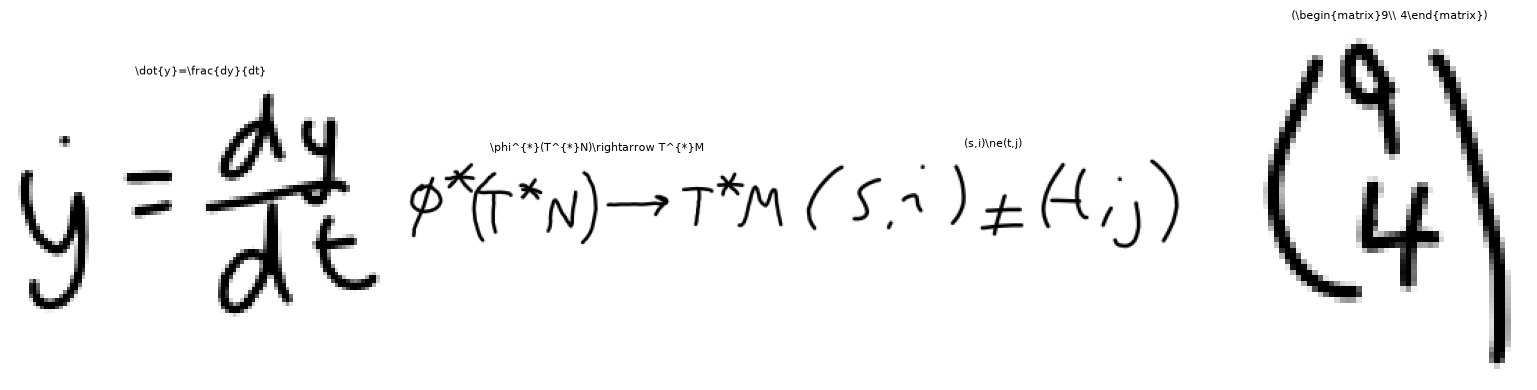

In [10]:
sample_records = records_by_split["train"][:4]
fig, axes = plt.subplots(1, len(sample_records), figsize=(16, 4))

for ax, rec in zip(axes, sample_records):
    img_path = OUTPUT_DIR / "images" / "train" / f"{rec['sample_id']}.png"
    ax.imshow(Image.open(img_path), cmap="gray")
    ax.set_title(rec["normalized_label"], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Augmentation QA

Visually validates the finalized augmentation policy on real `train` samples, saved separately to `augmented_demo/` (kept apart from `processed/`, which must stay clean). For each of a few samples we show the clean baseline plus 3 **independent fresh draws** from `render_with_augmentation` — i.e. exactly what a training `Dataset` would produce across different epochs — to eyeball whether stacked transforms still look like legible handwriting rather than isolating each transform in a vacuum.

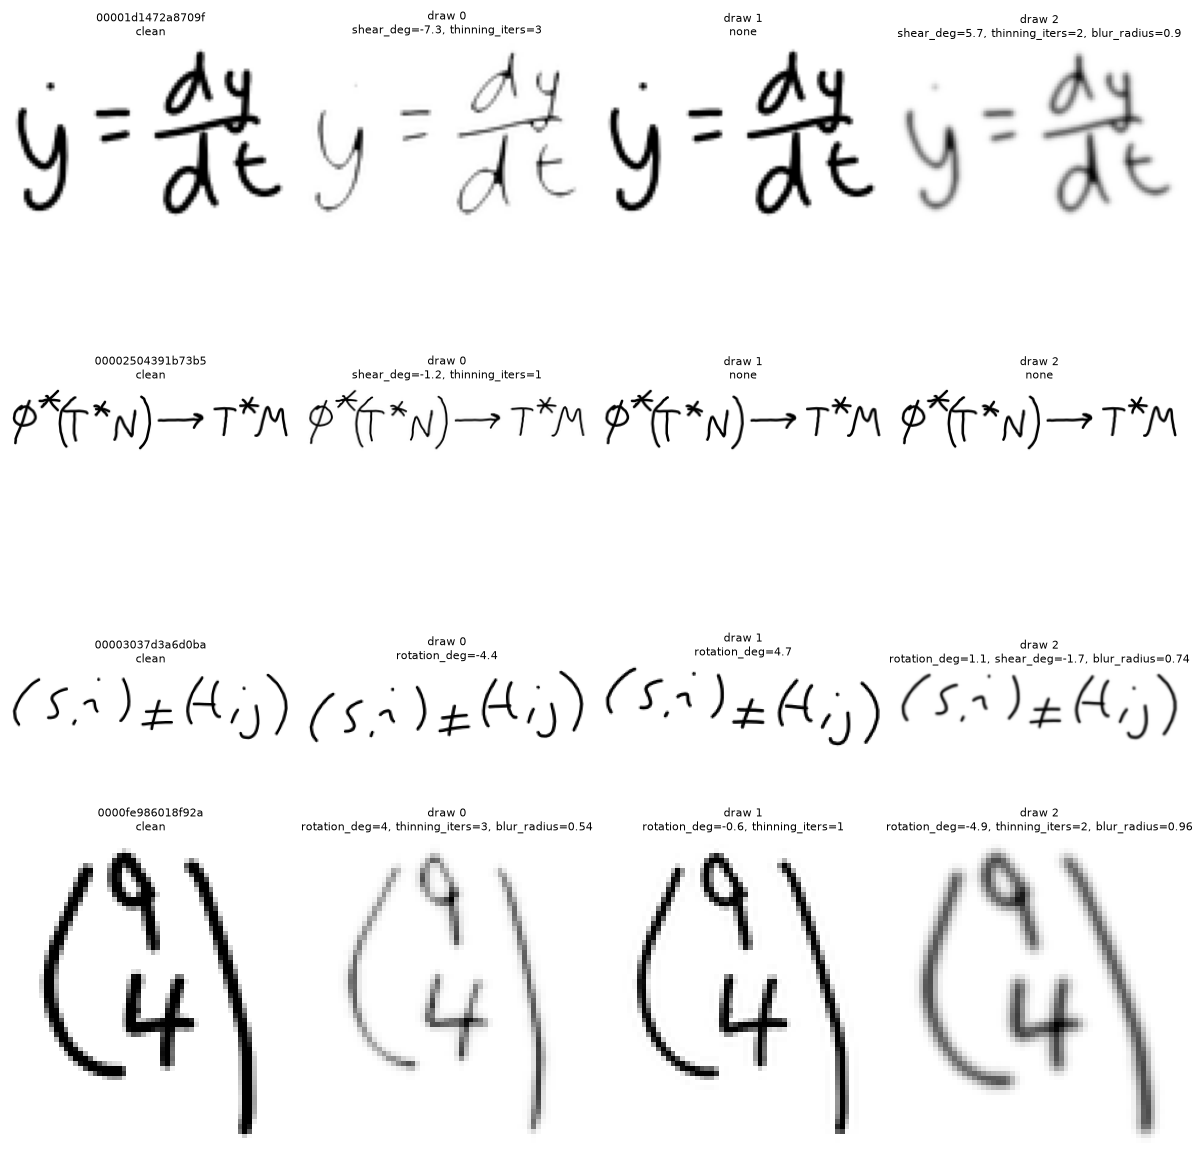

In [11]:
AUG_QA_DIR = Path("augmented_demo")
AUG_QA_DIR.mkdir(parents=True, exist_ok=True)

qa_rng = np.random.default_rng(RNG_SEED)
qa_sample_ids = [rec["sample_id"] for rec in records_by_split["train"][:4]]
n_draws_per_sample = 3

qa_records = []
for sample_id in qa_sample_ids:
    ink = read_inkml_file(ROOT_DIR / "train" / f"{sample_id}.inkml")
    normalized_ink = rescale_to_height(ink)

    base_canvas_ink, base_width, base_height = fit_canvas(normalized_ink)
    base_image = render_ink(base_canvas_ink, base_width, base_height)
    base_path = AUG_QA_DIR / f"{sample_id}_clean.png"
    base_image.save(base_path)
    qa_records.append({"label": f"{sample_id}\nclean", "path": base_path})

    for draw_idx in range(n_draws_per_sample):
        image, width, height, applied = render_with_augmentation(normalized_ink, qa_rng)
        path = AUG_QA_DIR / f"{sample_id}_draw{draw_idx}.png"
        image.save(path)
        applied_str = ", ".join(f"{k}={v:.2g}" if isinstance(v, float) else f"{k}={v}"
                                 for k, v in applied.items()) or "none"
        qa_records.append({"label": f"draw {draw_idx}\n{applied_str}", "path": path})

n_cols = n_draws_per_sample + 1
n_rows = len(qa_sample_ids)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))

for row, sample_id in enumerate(qa_sample_ids):
    row_records = qa_records[row * n_cols:(row + 1) * n_cols]
    for ax, rec in zip(axes[row], row_records):
        ax.imshow(Image.open(rec["path"]), cmap="gray")
        ax.set_title(rec["label"], fontsize=8)
        ax.axis("off")

plt.tight_layout()
plt.show()